In [ ]:
import torch

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu128


In [ ]:
scaler = torch.tensor(5.0)

vector = torch.tensor([1.0, 2.0, 3.0])

matrix = torch.tensor([
    [1.0 , 2.0],
    [3.0, 4.0]
])

print("Scaler:", scaler)
print("Vector:", vector)
print("Matrix: \n", matrix)

print("Scaler shape:", scaler.shape)
print("Vector shape:", vector.shape)
print("Matrix shape:", matrix.shape)

print("\nКоличество измерений выводится через ndim")
print(scaler.ndim)
print(vector.ndim)
print(matrix.ndim)

Scaler: tensor(5.)
Vector: tensor([1., 2., 3.])
Matrix: 
 tensor([[1., 2.],
        [3., 4.]])
Scaler shape: torch.Size([])
Vector shape: torch.Size([3])
Matrix shape: torch.Size([2, 2])

Количество измерений выводится через ndim
0
1
2


Для признаков нейросети обычно исопльзуется `float32`

In [ ]:
X = torch.tensor(
    [
        [25, 50_000],
        [40, 120_000],
        [31, 75_000]
    ],
    dtype=torch.float32
)

print(X)
print(X.dtype)
print(X.shape)

tensor([[2.5000e+01, 5.0000e+04],
        [4.0000e+01, 1.2000e+05],
        [3.1000e+01, 7.5000e+04]])
torch.float32
torch.Size([3, 2])


Для меток классов тип зависит от задачи

**Это важно: неправильный тип целевой переменной - одна из самых частых ошибок**

In [ ]:
# Бинарная классификация с `DCEWithLogitsLoss`
y_binary = torch.tensor([0, 1, 0], dtype=torch.float32)


# Многокласовая классификация с `CrossEntropyLoss`
y_multiclass = torch.tensor([0, 2, 1], dtype=torch.long)

# Операции над тензорами

In [ ]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print(a + b)
print(a * b)
print(a.mean())
print(a.sum())

tensor([5., 7., 9.])
tensor([ 4., 10., 18.])
tensor(2.)
tensor(6.)


In [ ]:
# Поэлементарное умножение:
a * b

tensor([ 4., 10., 18.])

In [ ]:
# Матричное умножение:
a @ b

tensor(32.)

In [ ]:
# Матричное умножение:
X = torch.tensor([
    [1.0, 2.0],
    [3.0, 4.0]
])

W = torch.tensor([
    [0.5],
    [1.0]
])

result = X @ W

print(result)
print(result.shape)

tensor([[2.5000],
        [5.5000]])
torch.Size([2, 1])


Контроль форм тензоров является одной из важнейших привычек в PyTorch

# Преобразование NumPy ↔ PyTorch

In [ ]:
import numpy as np

numpy_array = np.array([1, 2, 3], dtype=np.float32)

tensor = torch.from_numpy(numpy_array)
back_to_numpy = tensor.numpy()

print(tensor)
print(back_to_numpy)

tensor([1., 2., 3.])
[1. 2. 3.]


В некоторых случаях NumPy-массив и тензор исопльзуют одну область памяти. Изменение одного объекта может изменить второй:

In [ ]:
tensor[0] = 100
print(tensor)
print(numpy_array)

tensor([100.,   2.,   3.])
[100.   2.   3.]


# Первое знакомство с GPU

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print(X.device)

Device: cuda
cpu


## Первое мини-задание

In [ ]:
import torch

X = torch.tensor([
    [2.0, 3.0],
    [4.0, 5.0],
    [6.0, 7.0]
])

W = torch.tensor([
    [0.5, 1.0],
    [1.5, -1.0]
])

b = torch.tensor([1.0, 2.0])

result = X @ W + b

print("X shape:", X.shape)
print("W spahe:", W.shape)
print("b shape:", b.shape)
print("Result:\n", result)
print("Result shape:", result.shape)

X shape: torch.Size([3, 2])
W spahe: torch.Size([2, 2])
b shape: torch.Size([2])
Result:
 tensor([[ 6.5000,  1.0000],
        [10.5000,  1.0000],
        [14.5000,  1.0000]])
Result shape: torch.Size([3, 2])


# Урок 2. Autograd и градиентный спуск

In [ ]:
import torch

# Зависимость y = 2x + 1

X = torch.tensor([1.0, 2.0, 3.0, 4.0])
y = torch.tensor([3.0, 5.0, 7.0, 9.0])

In [ ]:
# Параметр reqires_grad означает:
#   PyTorch должен отслеживать операции с этим тензором, чтобы впоследствии вычислить градиент

w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

In [ ]:
predictions = w * X + b
loss = ((predictions - y) ** 2).mean()

print("Predictions:", predictions)
print("Loss:", loss)

Predictions: tensor([0., 0., 0., 0.], grad_fn=<AddBackward0>)
Loss: tensor(41., grad_fn=<MeanBackward0>)


Поскольку `w` и `b` пока равны нулю predictions равны нулю

Значение `grad_fn` показывает, что PyTorch сохранил историю вычисления `loss`

## Вычисление градиентов

In [ ]:
loss.backward()

print("dL/dw:", w.grad)
print("dL/db:", b.grad)

dL/dw: tensor(-35.)
dL/db: tensor(-12.)


**loss.backward()** проходит по вычислительному графу в обратном направлении и вычисляет:

$$ \frac{\partial w}{\partial L} \quad \text{,} \quad \frac{\partial b}{\partial L} $$

Отрицательный градиент по `w` означает, что для уменьшения ошибки параметр `w` нужно увеличить

## Обновление параметров

Формула градиентного спуска:

$$ w_{\text{new}} = w_{\text{old}} - \eta \frac{\partial L}{\partial w} $$

где η - learning rate

In [ ]:
learning_rate = 0.01

with torch.no_grad():
  w -= learning_rate * w.grad
  b -= learning_rate * b.grad

print("New w:", w)
print("New b:", b)

New w: tensor(0.3500, requires_grad=True)
New b: tensor(0.1200, requires_grad=True)


### Обнуление градиентов

В PyTorch градиенты накапливаются:

```
w.grad.zero_()
b.grad.zero_()
```

Если этого не сделать, следующий вызов `backward()` прибавит новые градиенты к старым

Это полезно в некоторых продвинутых сценариях, но в обычном обучении градиенты обнуляют на каждом шаге

## Полный цикл обучения

In [ ]:
import torch

# Зависимость имеет вид y=4x+3

X = torch.tensor([1.0, 2.0, 3.0, 4.0])
y = torch.tensor([7.0, 11.0, 15.0, 19.0])

w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

learning_rate = 0.02
epochs = 1000

for epoch in range(epochs):
  # 1. Forward pass
  predictions = w * X + b

  # 2. Расчет ошибки
  loss = ((predictions - y) ** 2).mean()

  # 3. Расчет градиентов
  loss.backward()

  # 4. Обновление параметров
  with torch.no_grad():
    w -= learning_rate * w.grad
    b -= learning_rate * b.grad

  # 5. Обнуление градиентов
  w.grad.zero_()
  b.grad.zero_()

  if (epoch + 1) % 20 == 0:
    print(
        f"Epoch {epoch + 1:3d} | "
        f"Loss: {loss.item():.6f} |"
        f"w: {w.item():.4f} | "
        f"b: {b.item():.4f}"
    )

Epoch  20 | Loss: 0.287103 |w: 4.4419 | b: 1.6964
Epoch  40 | Loss: 0.225761 |w: 4.3931 | b: 1.8443
Epoch  60 | Loss: 0.177549 |w: 4.3486 | b: 1.9751
Epoch  80 | Loss: 0.139633 |w: 4.3091 | b: 2.0911
Epoch 100 | Loss: 0.109813 |w: 4.2741 | b: 2.1940
Epoch 120 | Loss: 0.086362 |w: 4.2431 | b: 2.2852
Epoch 140 | Loss: 0.067919 |w: 4.2156 | b: 2.3661
Epoch 160 | Loss: 0.053415 |w: 4.1912 | b: 2.4379
Epoch 180 | Loss: 0.042008 |w: 4.1696 | b: 2.5015
Epoch 200 | Loss: 0.033037 |w: 4.1504 | b: 2.5579
Epoch 220 | Loss: 0.025982 |w: 4.1333 | b: 2.6079
Epoch 240 | Loss: 0.020433 |w: 4.1183 | b: 2.6523
Epoch 260 | Loss: 0.016070 |w: 4.1049 | b: 2.6917
Epoch 280 | Loss: 0.012638 |w: 4.0930 | b: 2.7266
Epoch 300 | Loss: 0.009939 |w: 4.0825 | b: 2.7575
Epoch 320 | Loss: 0.007816 |w: 4.0731 | b: 2.7850
Epoch 340 | Loss: 0.006147 |w: 4.0649 | b: 2.8093
Epoch 360 | Loss: 0.004835 |w: 4.0575 | b: 2.8309
Epoch 380 | Loss: 0.003802 |w: 4.0510 | b: 2.8500
Epoch 400 | Loss: 0.002990 |w: 4.0452 | b: 2.8670


**Процесс обучения на схеме**

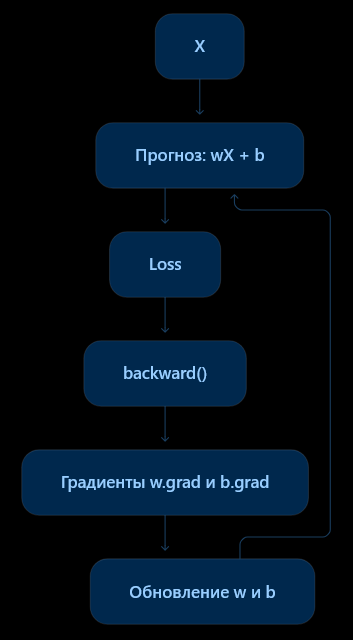

Практически любая сеть обучается по той же схеме. Разница лишь в том, что вместо двух параметров `w` и `b` могут быть миллионы или миллиарды параметров

# Урок 3. `nn.Module` и оптимизатор

В реальной работе параметры вручную не определяют:
```
w = torch.tensor(...)
b = torch.tensor(...)
```

Вместо этого слои PyTorch сами создают и регистрируют необходимые параметры

## Определяем модель

In [ ]:
import torch
from torch import nn

torch.manual_seed(42)

X = torch.tensor([
    [1.0],
    [2.0],
    [3.0],
    [4.0]
])

# y = torch.tensor([
#     [3.0],
#     [5.0],
#     [7.0],
#     [9.0]
# ])

y = torch.tensor([
    [7.0],
    [11.0],
    [15.0],
    [19.0]
])

print(X.shape)
print(y.shape)


torch.Size([4, 1])
torch.Size([4, 1])


Теперь создадим модель

In [ ]:
class LinearRegression(nn.Module):
  def __init__(self):
    super().__init__()

    self.linear = nn.Linear(
        in_features=1,
        out_features=1
    )

  def forward(self, x):
    return self.linear(x)


model = LinearRegression()
print(model)

LinearRegression(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


Слой `nn.Linear` выполняет:

$$ \hat{y} = xW^T + b $$

И сам создает:
  * матрицу весов `w`
  * вектор смещения `b`
  * для обоих параметров устанавливает `requires_grad = True`


## Что делает `nn.Module`

`nn.Module` - базовый класс для всех моделей и слоёв PyTorch

В `__init__` мы объявляем слои:

```
self.linear = nn.Linear(1, 1)
```

В `forward` описываем движение данных:

```
def forward(self, x):
    return self.linear(x)
```

Прямой проход запускается так:

```
predictions = model(X)
```

Напраямую писать:

```
model.forward(X)
```

не рекомендуется, поскольку вызов `model(X)` выполняет дополнительную внутренюю логику PyTorch


## Параметры модели

Посмотрим на начальные значения:

In [ ]:
for name, parameter in model.named_parameters():
  print(name)
  print(parameter)
  print("Required grad:", parameter.requires_grad)
  print()

linear.weight
Parameter containing:
tensor([[0.7645]], requires_grad=True)
Required grad: True

linear.bias
Parameter containing:
tensor([0.8300], requires_grad=True)
Required grad: True



Именно их будет изменять оптимизатор

## Функция потерь и оптимизатор




In [ ]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01
)


`model.parameters()` передает оптимизатору все обучаемые параметры модели

Теперь оптимизатор знает, какие значения нужно обновлять после расчета градиентов

## Полное обучение

In [ ]:
epochs = 1000

for epoch in range(epochs):
  # 1. Обнуляем старые градиенты
  optimizer.zero_grad()

  # 2. Forward pass
  predictions = model(X)

  # 3. Рассчитываем ошибку
  loss = loss_fn(predictions, y)

  # 4. Рассчитываем градиенты
  loss.backward()

  # 5. Обновляем параметры
  optimizer.step()

  if (epoch + 1) % 100 == 0:
    weight = model.linear.weight.item()
    bias = model.linear.bias.item()

    print(
        f"Epoch: {epoch + 1:4d} | "
        f"Loss: {loss.item():6f} | "
        f"w: {weight:.4f} | "
        f"b: {bias:.4f}"
    )

Epoch:  100 | Loss: 0.084767 | w: 4.2416 | b: 2.2897
Epoch:  200 | Loss: 0.046536 | w: 4.1790 | b: 2.4737
Epoch:  300 | Loss: 0.025548 | w: 4.1326 | b: 2.6101
Epoch:  400 | Loss: 0.014026 | w: 4.0983 | b: 2.7111
Epoch:  500 | Loss: 0.007700 | w: 4.0728 | b: 2.7859
Epoch:  600 | Loss: 0.004227 | w: 4.0539 | b: 2.8414
Epoch:  700 | Loss: 0.002321 | w: 4.0400 | b: 2.8825
Epoch:  800 | Loss: 0.001274 | w: 4.0296 | b: 2.9129
Epoch:  900 | Loss: 0.000699 | w: 4.0219 | b: 2.9355
Epoch: 1000 | Loss: 0.000384 | w: 4.0163 | b: 2.9522


Теперь нам больше не нужны:

```
with torch.no_grad():
  w -= learning_rate * w.grad
```

Эту работу выполняет:

```
optimizer.step()
```

Получается практически тот же алгортим:

| Вручную | Через PyTorch |
| :--- | :--- |
| Создать `w` и `b` | `nn.Linear` |
| Рассчитать MSE | `mm.MSELoss` |
| Изменить параметры | `optimizer.step()` |
| Обнулить `.grad` | `optimizer.zero_grad()` |



## Предсказание

После обучения переключаем модель в режим оценки:

In [ ]:
model.eval()

with torch.inference_mode():
  new_X = torch.tensor([[5.0]])
  prediction = model(new_X)

print(prediction)

tensor([[23.0335]])


`torch.inference_mode()` отключает построение вычислительного графа. При прогнозировании градиенты не нужны, поэтому такой режим экономит память и ускоряет вычисления

## Состояние модели

Все обученные параметры находятся в `state_dict`:

In [ ]:
print(model.state_dict())

OrderedDict({'linear.weight': tensor([[4.0163]]), 'linear.bias': tensor([2.9522])})


Именно `state_dict`, а не весь объект модели, обычно сохраняют в файл:

In [ ]:
torch.save(model.state_dict(), 'linear_model.pth')

# Урок 4. `Dataset`, `DataLoader` и батчи



До сих пор мы подавали модели весь датасет сразу:

```
predictions = model(X)
```

Однако так можно сделать не всегда, данные могу тне помещаться в память или видеопамять. Поэтому датасет разбивают на батчи.

Например, если:

```
Количество объектов: 10 000
batch_size: 32
```

модель получает по 32 объекта и после каждого батча обновляет параметры

## Три основных понятия

* `Dataset` хранит объекты и позволяет получить объект по индексу
* `DataLoader` формирует батчи, перемешивает данные и итерируется по датасету
* `Epoch` - один полный проход по всему датасету

## Создаем `Dataset`

Возьмем зависимость:
$$ y = 4x + 3 $$

In [ ]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)

X = torch.arange(
    start=1,
    end=11,
    dtype=torch.float32,
).reshape(-1, 1)

y = 4 * X + 3

print(X)
print(y)
print(X.shape)
print(y.shape)

tensor([[ 1.],
        [ 2.],
        [ 3.],
        [ 4.],
        [ 5.],
        [ 6.],
        [ 7.],
        [ 8.],
        [ 9.],
        [10.]])
tensor([[ 7.],
        [11.],
        [15.],
        [19.],
        [23.],
        [27.],
        [31.],
        [35.],
        [39.],
        [43.]])
torch.Size([10, 1])
torch.Size([10, 1])


Теперь объединим признаки и целевую переменную:

In [ ]:
dataset = TensorDataset(X, y)

print("Dataset size:", len(dataset))
print("First object:", dataset[0])

Dataset size: 10
First object: (tensor([1.]), tensor([7.]))


`TensorDataset` предполагает, что первая размерность всех переданных тензоров одинакова:

```
X.shape = (10, 1)
y.shape = (10, 1)
```


## Создаем `DataLoader`

In [ ]:
train_loader = DataLoader(
    dataset,
    batch_size=3,
    shuffle=True
)

# Смотрим на сформированные батчи
for batch_number, (X_batch, y_batch) in enumerate(train_loader):
  print(f"Batch {batch_number + 1}")
  print("X", X_batch.flatten().tolist())
  print("y", y_batch.flatten().tolist())
  print("X shape", X_batch.shape)
  print()

Batch 1
X [9.0, 6.0, 8.0]
y [39.0, 27.0, 35.0]
X shape torch.Size([3, 1])

Batch 2
X [2.0, 4.0, 7.0]
y [11.0, 19.0, 31.0]
X shape torch.Size([3, 1])

Batch 3
X [10.0, 1.0, 3.0]
y [43.0, 7.0, 15.0]
X shape torch.Size([3, 1])

Batch 4
X [5.0]
y [23.0]
X shape torch.Size([1, 1])



Последний батч меньше остальных из-за того, что у нас `batch_size = 3`, а объектов 10, т.е.:
```
3 + 3 + 3 + 1
```

Последний батч можно отбросить с помощью:

```
DataLoader(dataset, batch_size=3, drop_last=True)
```

Но без необходимости терять данные не стоит


## Зачем нужен `shuffle=True`

Перед каждой эпохой `DataLoader` меняет порядок объектов

Это помогает модели не привязываться к порядку строк и делает мини-батчи разнообразнее

Обычно используют:
```
train_loader = DataLoader(
  train_dataset,
  batch_size=32,
  shuffle=True
)

val_loader = DataLoader(
  val_dataset,
  batch_size=32,
  shuffle=False
)
```

На валидации параметры не обновляются, поэтому перемешивание обычно не требуется

## Обучение по батчам

Определим модель:

In [ ]:
class LinearRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Linear(1, 1)

  def forward(self, x):
    return self.linear(x)


model = LinearRegression()

loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.001
)

Теперь внутри каждой эпохи появляется цикл по батчам:

In [ ]:
epochs = 1000

for epoch in range(epochs):
  epoch_loss = 0

  for X_batch, y_batch in train_loader:

    # обнуляем градиенты
    optimizer.zero_grad()

    # получаем предсказания для текущего батча
    predictions = model(X_batch)

    # Рассчитываем ошбику текущего батча
    loss = loss_fn(predictions, y_batch)

    # Рассчитываем градиенты
    loss.backward()

    # Обновляем параметры
    optimizer.step()

    epoch_loss += loss.item() * len(X_batch)

  epoch_loss /= len(dataset)

  if (epoch + 1) % 100 == 0:
    weight = model.linear.weight.item()
    bias = model.linear.bias.item()

    print(
        f"Epoch: {epoch + 1:4d} | "
        f"Loss: {epoch_loss:.6f} | "
        f"w: {weight:.4f} | "
        f"b: {bias:.4f}"
    )

Epoch:  100 | Loss: 1.814189 | w: 4.4041 | b: 0.1050
Epoch:  200 | Loss: 1.289180 | w: 4.3541 | b: 0.5615
Epoch:  300 | Loss: 0.907815 | w: 4.2900 | b: 0.9515
Epoch:  400 | Loss: 0.646885 | w: 4.2617 | b: 1.2795
Epoch:  500 | Loss: 0.455083 | w: 4.2078 | b: 1.5469
Epoch:  600 | Loss: 0.325045 | w: 4.1805 | b: 1.7719
Epoch:  700 | Loss: 0.234731 | w: 4.1484 | b: 1.9617
Epoch:  800 | Loss: 0.167855 | w: 4.1224 | b: 2.1220
Epoch:  900 | Loss: 0.119736 | w: 4.1068 | b: 2.2572
Epoch: 1000 | Loss: 0.084057 | w: 4.0893 | b: 2.3754


Важное изменение: теперь за одну эпоху выполняется не один, а четыре вызова

```
optimizer.step()
```

Параметры обновляются после каждого батча

### Почему `loss` умножается на размер батча

```
epoch_loss += loss.item() * len(X_batch)
```

`nn.MSELoss()` возвращает среднюю ошибку внутри батча. Последний батч содержит только один объект, а остальные - по три

Если просто усреднить четыре значения `loss`, последний объект получит такой же вес, как целый батч из трёх объектов. Поэтому мы сначала восстанавливаем сумму ошибок, а затм делим ее на количество объектов:

```
epoch_loss /= len(dataset)
```

## Предсказание после обучения

In [ ]:
model.eval()

with torch.inference_mode():
  new_X = torch.tensor([[5.0]])
  prediction = model(new_X)

print("Prediction:", prediction.item())

Prediction: 22.82176971435547


# Урок 5. Обучающая и валидационная выборки

Теперь соберем нормальный шаблон обучения:
  * разделим данные
  * создадим два `DataLoader`
  * напишем отдельные функции обучения и оценки
  * будем отслеживать `train_loss` и `val_loss`

## Генерация данных

Создадим линейную зависимость с шумом:

$$ y = 4x + 3 + \epsilon $$

In [ ]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, random_split

torch.manual_seed(42)

X = torch.linspace(-2, 2, 200).reshape(-1, 1)
noise = torch.randn_like(X) * 0.5
y = 4 * X + 3 + noise

dataset = TensorDataset(X, y)

print("Dataset size:", len(dataset))
print("X shape:", X.shape)
print("y shape", y.shape)

Dataset size: 200
X shape: torch.Size([200, 1])
y shape torch.Size([200, 1])


Теперь идеального решения с нулевым `loss` не будет, потом учто в целевую переменную добавлен случайный шум

## Разделение данных

In [ ]:
train_size = 160
val_size =40

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    dataset,
    lengths=[train_size, val_size],
    generator=generator
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

Train size: 160
Validation size: 40


`generator` с фиксированным seed позволяет получить одинаковое разделение при повторных запусках

## Создание DataLoader

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches", len(val_loader)) # 16 + 16 + 8

Train batches: 10
Validation batches 3


## Модель

In [ ]:
class LinearRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Linear(1, 1)

  def forward(self, x):
    return self.linear(x)


model = LinearRegression()
loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.03
)

## Функция обновления

In [ ]:
def train_one_epoch(model, dataloader, loss_fn, optimizer):
  model.train()

  total_loss = 0

  for X_batch, y_batch in dataloader:
    optimizer.zero_grad()

    predictions = model(X_batch)

    loss = loss_fn(predictions, y_batch)

    loss.backward()
    optimizer.step()

    total_loss += loss.item() * len(X_batch)

  average_loss = total_loss / len(dataloader.dataset)

  return average_loss

В начале вызывается

```
model.train()
```

Это переключает модель в режим обучения. Для `nn.Linear` пока ничего не меняется, но позже это будет важно для `Dropout` и `BatchNorm`

## Функция валидации

In [ ]:
def evaluate(model, dataloader, loss_fn):
  model.eval()

  total_loss = 0

  with torch.inference_mode():
    for X_batch, y_batch in dataloader:
      predictions = model(X_batch)
      loss = loss_fn(predictions, y_batch)

      total_loss += loss.item() * len(X_batch)

  average_loss = total_loss / len(dataloader.dataset)

  return average_loss

На валидации отсутствуют:

```
loss.backward()
optimizer.step()
```

Валидационная выборка используется только для проверки. Модель не должна обучаться на ней


## `model.eval()` и `torch.inference_mode()`

Они выполняют разные задачи:

```
model.eval()
```

переключает поведение отдельных слоев, прежде всего `Dropout` и `BatchNorm`

```
with torch.inference_mode():
```

отключает построение вычислительного графа и расчет градиентов

При оценке модели обычно нужны оба


## Полный цикл

In [ ]:
epochs = 200

train_history = []
val_history = []

for epoch in range(epochs):
  train_loss = train_one_epoch(
      model,
      train_loader,
      loss_fn,
      optimizer
  )

  val_loss = evaluate(
      model,
      val_loader,
      loss_fn
  )

  train_history.append(train_loss)
  val_history.append(val_loss)

  if (epoch + 1) % 20 == 0:
    weight = model.linear.weight.item()
    bias = model.linear.bias.item()

    print(
        f"Epoch: {epoch + 1:3d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"w: {weight:.4f} | "
        f"b: {bias:.4f}"
    )

Epoch:  20 | Train loss: 0.2062 | Val loss: 0.3819 | w: 3.9980 | b: 3.0364
Epoch:  40 | Train loss: 0.2059 | Val loss: 0.3811 | w: 3.9970 | b: 3.0316
Epoch:  60 | Train loss: 0.2060 | Val loss: 0.3824 | w: 4.0000 | b: 3.0364
Epoch:  80 | Train loss: 0.2063 | Val loss: 0.3807 | w: 3.9955 | b: 3.0311
Epoch: 100 | Train loss: 0.2059 | Val loss: 0.3811 | w: 3.9985 | b: 3.0283
Epoch: 120 | Train loss: 0.2058 | Val loss: 0.3820 | w: 4.0021 | b: 3.0279
Epoch: 140 | Train loss: 0.2057 | Val loss: 0.3809 | w: 3.9962 | b: 3.0315
Epoch: 160 | Train loss: 0.2056 | Val loss: 0.3809 | w: 3.9965 | b: 3.0304
Epoch: 180 | Train loss: 0.2056 | Val loss: 0.3826 | w: 4.0028 | b: 3.0320
Epoch: 200 | Train loss: 0.2068 | Val loss: 0.3831 | w: 4.0044 | b: 3.0330


Параметры находятся около:
```
w = 4
b = 3
```

Но из-за добавленного шума никогда им не равны


## Построение графика


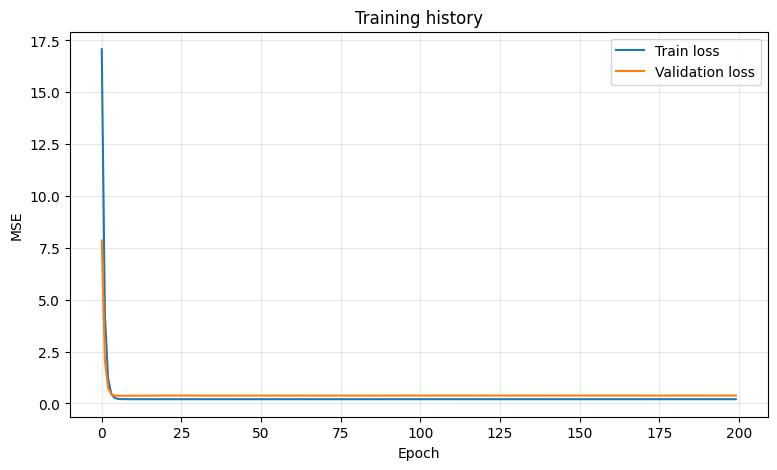

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(train_history, label='Train loss')
plt.plot(val_history, label='Validation loss')

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training history")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Урок 6. Первая настоящая нейросеть


До сих пор наша модель состояла из одного линейного слоя:

```
nn.Linear(1, 1)
```

Теперь построим многословную нейросеть для классификации изображений одежды из Fashion MNIST

Каждое изображение:
  * черно-белое
  * размером 28 × 28
  * относится к одному из 10 объектов


## Загрузка данных

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

torch.manual_seed(42)

transform = transforms.ToTensor()

full_train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    lengths=[54_000, 6000],
    generator=torch.Generator().manual_seed(42)
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 54000
Validation: 6000
Test: 10000


Создадим загрузчики:

In [ ]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

Посмотрим на один батч

In [ ]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Images dtype:", images.dtype)
print("Labels dtype", images.dtype)

Images: torch.Size([64, 1, 28, 28])
Labels: torch.Size([64])
Images dtype: torch.float32
Labels dtype torch.float32


Размерность изображений означают:

```
[batch_size, channels, height, width]
[64,         1,        28,     28   ]
```


## Архитектура модели

In [ ]:
class FashionMLP(nn.Module):
  def __init__(self):
    super().__init__()

    self.network = nn.Sequential(
        nn.Flatten(),

        nn.Linear(28 * 28, 256),
        nn.ReLU(),

        nn.Linear(256, 128),
        nn.ReLU(),

        nn.Linear(128, 10)
    )

  def forward(self, x):
    return self.network(x)

Создадим модель и выберем устройство:

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = FashionMLP().to(device)

print("Device:", device)
print(model)

Device: cuda
FashionMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


## Как меняются формы

Для батча из 64 изображений:

```
Изображения:      [64, 1, 28, 28]
После Flatten:    [64, 784]
Первый Linear:    [64, 256]
Второй Linear:    [64, 128]
Последний Linear  [64, 10]
```

Последние десять чисел - оценки принадлежности изображения каждому классу. Они называются `logits`


## Зачем нужен ReLU

Линейный слой выполняет линейное преобразование:

$$ z = xW^T + b $$

Если соединить несколько линейных слоев без функций активации, вся конструкция все равно останется одним линейным преобразованием:

$$ W_{3}(W_{2}(W_{1}x)) = Wx $$

`ReLU` добавляет нелинейность:

$$ ReLU(x) = max(0, x) $$

Благодаря этому сеть может изучить сложные зависимости


## Loss и оптимизатор


In [ ]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
)

`nn.CrossEntropyLoss` используется для многоклассовой классификации

Важно: добавлять `Softmax` в модель сейчас не нужно. `nn.CrossEntropy` принимает исходные `logits` и сама выполняет необходимое преобразование в численно устойчивой форме

Целевые классы должны иметь вид:
```
[2, 7, 1, 0, ...]
```

и тип:
```
torch.int64 # torch.long
```


## Функция обучения

In [ ]:
def train_one_epoch(
    model,
    dataloader,
    loss_fn,
    optimizer,
    device
):

  model.train()

  total_loss = 0
  total_correct = 0
  total_objects = 0

  for images, labels in dataloader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    logits = model(images)
    loss = loss_fn(logits, labels)

    loss.backward()
    optimizer.step()

    batch_size = len(images)

    total_loss += loss.item() * batch_size
    total_correct += (
        logits.argmax(dim=1) == labels
    ).sum().item()
    total_objects += batch_size

  average_loss = total_loss / total_objects
  accuracy = total_correct / total_objects

  return average_loss, accuracy

`logits.argmax(dim=1)` выбирает класс с максимальной оценкой для каждого изображения

## Функция оценки

In [ ]:
def evaluate(model, dataloader, loss_fn, device):
  model.eval()

  total_loss = 0
  total_correct = 0
  total_objects = 0

  with torch.inference_mode():
    for images, labels in dataloader:
      images = images.to(device)
      labels = labels.to(device)

      logits = model(images)
      loss = loss_fn(logits, labels)

      batch_size = len(images)

      total_loss += loss.item() * batch_size
      total_correct += (
          logits.argmax(dim=1) == labels
      ).sum().item()
      total_objects += batch_size

  average_loss = total_loss / total_objects
  accuracy = total_correct / total_objects

  return average_loss, accuracy

## Обучение

In [ ]:
epochs = 5

train_loss_history = []
val_loss_history = []

for epoch in range(epochs):
  train_loss, train_accuracy = train_one_epoch(
      model,
      train_loader,
      loss_fn,
      optimizer,
      device,
  )

  val_loss, val_accuracy = evaluate(
      model,
      val_loader,
      loss_fn,
      device,
  )

  train_loss_history.append(train_loss)
  val_loss_history.append(val_loss)

  print(
      f"Epoch: {epoch + 1} / {epochs} | "
      f"Train loss: {train_loss:.4f} | "
      f"Train accuracy: {train_accuracy:.2%} | "
      f"Val loss: {val_loss:.4f} | "
      f"Val accuracy: {val_accuracy:.2%}"
  )

Epoch: 1 / 5 | Train loss: 0.5371 | Train accuracy: 80.75% | Val loss: 0.4206 | Val accuracy: 84.88%
Epoch: 2 / 5 | Train loss: 0.3760 | Train accuracy: 86.36% | Val loss: 0.4047 | Val accuracy: 85.05%
Epoch: 3 / 5 | Train loss: 0.3368 | Train accuracy: 87.67% | Val loss: 0.3877 | Val accuracy: 86.00%
Epoch: 4 / 5 | Train loss: 0.3144 | Train accuracy: 88.40% | Val loss: 0.3353 | Val accuracy: 87.38%
Epoch: 5 / 5 | Train loss: 0.2942 | Train accuracy: 89.15% | Val loss: 0.3353 | Val accuracy: 87.65%


## Финальная оценка

Тест используется только после завершения обучения:

In [ ]:
test_loss, test_accuracy = evaluate(
    model,
    test_loader,
    loss_fn,
    device,
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test loss: 0.3551
Test accuracy: 87.28%


## Получение вероятностей

По время обучения мы передавали в `CrossEntropyLoss` logits. Но для интерпретации предсказания можем получить вероятности:

In [ ]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

model.eval()

with torch.inference_mode():
  image, true_labels = test_dataset[0]

  logits = model(image.unsqueeze(0).to(device))
  probabilities = torch.softmax(logits, dim=1)

  predicted_label = probabilities.argmax(dim=1).item()
  confidence = probabilities[0, predicted_label].item()

print("True:", class_names[true_labels])
print("Prediction:", class_names[predicted_label])
print(f"Confidence: {confidence:.2%}")

True: Ankle boot
Prediction: Ankle boot
Confidence: 99.35%


`image` имеет форму `[1, 28, 28]`, а модель ожидает батч `[N, 1, 28, 28]`. Поэтому:

```
image.unsqueeze(0)
```

добавляет размерность батча

```
[1, 28, 28] → [1, 1, 28, 28]
```

# Урок 7. Сверточные нейронные сети - CNN


Функции `train_one_epoch()` и `evaluate()` и загрузчики из предыдущего урока переносятся этот урок

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

torch.manual_seed(42)

transform = transforms.ToTensor()

full_train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    lengths=[54_000, 6000],
    generator=torch.Generator().manual_seed(42)
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.16MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.1MB/s]

Train: 54000
Validation: 6000
Test: 10000


In [ ]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

In [ ]:
def train_one_epoch(
    model,
    dataloader,
    loss_fn,
    optimizer,
    device
):

  model.train()

  total_loss = 0
  total_correct = 0
  total_objects = 0

  for images, labels in dataloader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    logits = model(images)
    loss = loss_fn(logits, labels)

    loss.backward()
    optimizer.step()

    batch_size = len(images)

    total_loss += loss.item() * batch_size
    total_correct += (
        logits.argmax(dim=1) == labels
    ).sum().item()
    total_objects += batch_size

  average_loss = total_loss / total_objects
  accuracy = total_correct / total_objects

  return average_loss, accuracy



def evaluate(model, dataloader, loss_fn, device):
  model.eval()

  total_loss = 0
  total_correct = 0
  total_objects = 0

  with torch.inference_mode():
    for images, labels in dataloader:
      images = images.to(device)
      labels = labels.to(device)

      logits = model(images)
      loss = loss_fn(logits, labels)

      batch_size = len(images)

      total_loss += loss.item() * batch_size
      total_correct += (
          logits.argmax(dim=1) == labels
      ).sum().item()
      total_objects += batch_size

  average_loss = total_loss / total_objects
  accuracy = total_correct / total_objects

  return average_loss, accuracy

В MLP мы сразу превращали изображение в вектор из 784 чисел. Значения пикселей сохранялись, но архитектура не исопльзовала специально то, что сосоедние пиксели образуют линии, границы и другие локальные структуры.

CNN начинает с обработки небольших участков изображения, сохраняя их пространственное расположение

## Как работает свертка

Можно представить матрицу обучаемых весов размером 3 × 3. Она называется _ядром_, или _фильтром_.

Для однократного изображения фильтр:

  1. Берет участок из девяти пикселей
  2. Умножает значения пикселей на соответствующие веса
  3. Складывает результаты и добавляет смещение
  4. Перемещается к следующему участку

Получается новая двумерная таблица - **карта признаков**. Ее значения показывают отклик фильтра в разных местах изображения

Самое существенное: **одни и те же веса применяются в разных местах изображения**. Поэтому фильтр может реагировать на похожую структуру и слева, и справа. Веса фильтра обучаются через уже знакомые `backward()` и `optimizer.step()`

Например:
```
nn.Conv2d(
  in_channels=1,
  out_channels=16,
  kernel_size=3,
  stride=1,
  padding=1,
)
```

| Параметр | Значение |
| :--- | :--- |
| `in_channels=1` | На входе один канал яркости |
| `out_channels=16` | На выходе 16 карт признаков |
| `kernel_size=3` | Фильтры обрабатывают участи 3 × 3 |
| `stride=1` | Шаг перемещения - один пиксель |
| `padding=1` | По краям добавляется рамка нулей шириной один пиксель |


При таком сочетании размера ядра, шага и отступов высота и ширина сохраняются: 28 × 28.

Для батча из 64 изображений:
$$ [64, 1, 28, 28] → [64, 16, 28, 28] $$

Объектов по-прежнему 64. У каждого теперь 16 карт признаков. **Это не 16 классов** - это промежуточное представление


## Как уменьшать карты признаков

Добавим `MaxPool2d`:

```
nn.MaxPool2d(kernel_size=2, stride=2)
```

Он берет максимальное значение в каждом окне 2 × 2 и перемещает окно с шагом 2. Например:

$$
\begin{bmatrix}
1 & 3 \\
2 & 0
\end{bmatrix}
→ 3
$$

Каждая карта 28 × 28 превращается 14 × 14. Число каналов сохраняется. Обучаемых весов у этой операции нет

## Соберем модель

In [ ]:
import torch
from torch import nn

class FashionCNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.features = nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(32 * 7 * 7, 10),
    )

  def forward(self, x):
    x = self.features(x)
    logits = self.classifier(x)
    return logits

Вторая свертка принимает все 16 входных каналов. Каждый из ее 32 фильтров объединяет информацию из участков 3 × 3 **во всех 16 каналах**, создавая одну выходную карту

Формы в нашей сети:

| Операция | Форма выхода |
| :--- | :--- |
| Вход | `[64, 1, 28, 28]` |
| Первая свертка + ReLU | `[64, 16, 28, 28]` |
| Первый MaxPool | `[64, 16, 14, 14]` |
| Вторая свертка + ReLU | `[64, 32, 14, 14]` |
| Второй MaxPool | `[64, 32, 7, 7]` |
| Flatten | `[64, 1568]` |
| Linear | `[64, 10]` |


Теперь понятно, откуда берется `32 * 7 * 7`: у каждого изображения перед класификатором 32 карты размером 7 × 7


## Проверка прохождения данных

In [ ]:
torch.manual_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

cnn_model = FashionCNN().to(device)

images, labels = next(iter(train_loader))

cnn_model.eval()

with torch.inference_mode():
  x = images.to(device)
  print("Input:", tuple(x.shape))

  for layer in cnn_model.features:
    x = layer(x)
    print(type(layer).__name__, tuple(x.shape))

  for layer in cnn_model.classifier:
    x = layer(x)
    print(type(layer).__name__, tuple(x.shape))

Input: (64, 1, 28, 28)
Conv2d (64, 16, 28, 28)
ReLU (64, 16, 28, 28)
MaxPool2d (64, 16, 14, 14)
Conv2d (64, 32, 14, 14)
ReLU (64, 32, 14, 14)
MaxPool2d (64, 32, 7, 7)
Flatten (64, 1568)
Linear (64, 10)


Так можно видеть формы на каждом шаге и находить ошибки до обучения


## Обучим CNN

Для новой модели обязательно создаем **новый оптимизатор**: старый содержит ссылки на параметры MLP

In [ ]:
loss_fn = nn.CrossEntropyLoss()

cnn_optimizer = torch.optim.Adam(
    cnn_model.parameters(),
    lr=0.001,
)

epochs = 5
cnn_history = []

for epoch in range(epochs):
  train_loss, train_accuracy = train_one_epoch(
      cnn_model,
      train_loader,
      loss_fn,
      cnn_optimizer,
      device,
  )

  val_loss, val_accuracy  = evaluate(
      cnn_model,
      val_loader,
      loss_fn,
      device,
  )

  cnn_history.append({
      'train_loss': train_loss,
      'train_accuracy': train_accuracy,
      'val_loss': val_loss,
      'val_accuracy': val_accuracy
  })

  print(
      f"Epoch: {epoch + 1}/{epochs} | "
      f"Train loss: {train_loss:.4f} | "
      f"Train accuracy: {train_accuracy:.2%} | "
      f"Val loss: {val_loss:.4f} | "
      f"Val accuracy: {val_accuracy:.2%}"
  )

Epoch: 1/5 | Train loss: 0.5360 | Train accuracy: 80.97% | Val loss: 0.3940 | Val accuracy: 85.70%
Epoch: 2/5 | Train loss: 0.3537 | Train accuracy: 87.39% | Val loss: 0.3345 | Val accuracy: 88.32%
Epoch: 3/5 | Train loss: 0.3140 | Train accuracy: 88.83% | Val loss: 0.3081 | Val accuracy: 89.07%
Epoch: 4/5 | Train loss: 0.2862 | Train accuracy: 89.86% | Val loss: 0.3034 | Val accuracy: 89.62%
Epoch: 5/5 | Train loss: 0.2717 | Train accuracy: 90.29% | Val loss: 0.2846 | Val accuracy: 90.03%


# Урок 8. Сохранение лучшей модели

Теперь необходимо научиться **сохранять лучшую версию модели и останавливать обучение, когда валидационная выборка перестает улучшаться**. Это две связанные, но разные задачи.

Пример:

| Эпоха | Vall loss | Действие |
| :--- | :--- | :--- |
| 1 | 0.40 | Сохраняем модель |
| 2 | 0.32 | Обновляем сохранение |
| 3 | 0.28 | Обновляем сохранение |
| 4 | 0.29 | Первое отсутствие улучшения |
| 5 | 0.30 | Второе отсутствие улучшения |
| 6 | 0.31 | Третье - останавливаемся |

При `patience = 3` мы допускаем **три последовательные эпохи без нового лучшего результата**. Останавливаемся после шестой, но для предсказаний загружаем веса третьей

Это называется _early stopping_ - ранняя остановка. Она может сократить лишние вычисления и ограничить переобучение. При этом небольшие колебания метрики сами по себе еще не доказывают переобучение.

В этом уроке критерием выбора будет **минимальный** `val_loss`. Лучшая эпоха по accuracy может отличаться


## Что именно сохраняем

У модели есть метод:
```
cnn_model.state_dict()
```

Он возвращает словарь с параметрами и сохраняемыми буферами модели. У нашей CNN это веса и смещения слоев.

Сохранить их можно через `torch.save()`, а восстановить через `load_state_dict()`. Само описание архитектуры в такой словарь не входит: перед загрузкой нужно создать модель с соответствующий структурой

Мы сохраним вместе с весами номер эпохи и валидационные метрики - такой набор удобно называть `checkpoint`, или контрольной точкой


## Обучение с сохранением и ранней остановкой

Используем `FashionCNN`, `train_loader`, `val_loader`, `train_one_epoch()` и `evaluate()` из предыдущих уроков



In [13]:
import torch
from torch import nn

class FashionCNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.features = nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(32 * 7 * 7, 10),
    )

  def forward(self, x):
    x = self.features(x)
    logits = self.classifier(x)
    return logits


def train_one_epoch(
    model,
    dataloader,
    loss_fn,
    optimizer,
    device
):

  model.train()

  total_loss = 0
  total_correct = 0
  total_objects = 0

  for images, labels in dataloader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    logits = model(images)
    loss = loss_fn(logits, labels)

    loss.backward()
    optimizer.step()

    batch_size = len(images)

    total_loss += loss.item() * batch_size
    total_correct += (
        logits.argmax(dim=1) == labels
    ).sum().item()
    total_objects += batch_size

  average_loss = total_loss / total_objects
  accuracy = total_correct / total_objects

  return average_loss, accuracy


def evaluate(model, dataloader, loss_fn, device):
  model.eval()

  total_loss = 0
  total_correct = 0
  total_objects = 0

  with torch.inference_mode():
    for images, labels in dataloader:
      images = images.to(device)
      labels = labels.to(device)

      logits = model(images)
      loss = loss_fn(logits, labels)

      batch_size = len(images)

      total_loss += loss.item() * batch_size
      total_correct += (
          logits.argmax(dim=1) == labels
      ).sum().item()
      total_objects += batch_size

  average_loss = total_loss / total_objects
  accuracy = total_correct / total_objects

  return average_loss, accuracy



In [14]:
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms


# Выгрузка данных
torch.manual_seed(42)

transform = transforms.ToTensor()

full_train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    lengths=[54_000, 6000],
    generator=torch.Generator().manual_seed(42)
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))



# Разделение на выборки
transform = transforms.ToTensor()

full_train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    lengths=[54_000, 6000],
    generator=torch.Generator().manual_seed(42)
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


# Разделение на батчи
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

Train: 54000
Validation: 6000
Test: 10000
Train: 54000
Validation: 6000
Test: 10000


Для этого эксперимента создадим новую CNN и обучим ее с начала:

In [15]:
from pathlib import Path

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

cnn_model = FashionCNN().to(device)

cnn_optimizer = torch.optim.Adam(
    cnn_model.parameters(),
    lr=0.001,
)

loss_fn = nn.CrossEntropyLoss()

checkpoint_path = Path("checkpoints/fashion_cnn_best.pth")
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

max_epochs = 20
patience = 3

best_val_loss = float("inf")
best_epoch = None
epochs_without_improvement = 0

history = []

for epoch in range(1, max_epochs+1):
    train_loss, train_accuracy = train_one_epoch(
        cnn_model,
        train_loader,
        loss_fn,
        cnn_optimizer,
        device
    )

    val_loss, val_accuracy = evaluate(
        cnn_model,
        val_loader,
        loss_fn,
        device
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
    })

    if val_loss < best_val_loss:
      best_val_loss = val_loss
      best_epoch = epoch
      epochs_without_improvement = 0

      torch.save(
          {
              "model_state_dict": cnn_model.state_dict(),
              "epoch": epoch,
              "val_loss": val_loss,
              "val_accuracy": val_accuracy,
          },
          checkpoint_path,
      )

      status = "saved"
    else:
      epochs_without_improvement += 1
      status = (
          f"no improvement: "
          f"{epochs_without_improvement}/{patience}"
      )

    print(
        f"Epoch {epoch:2d}/{max_epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val accuracy: {val_accuracy:.2%} | "
        f"{status}"
    )

    if epochs_without_improvement >= patience:
      print("Early stopping")
      break

print(
    f"Best epoch: {best_epoch} | "
    f"Best val loss: {best_val_loss:.4f}"
)

Epoch  1/20 | Train loss: 0.5430 | Val loss: 0.3915 | Val accuracy: 86.13% | saved
Epoch  2/20 | Train loss: 0.3522 | Val loss: 0.3414 | Val accuracy: 87.62% | saved
Epoch  3/20 | Train loss: 0.3137 | Val loss: 0.3104 | Val accuracy: 89.18% | saved
Epoch  4/20 | Train loss: 0.2915 | Val loss: 0.2914 | Val accuracy: 89.65% | saved
Epoch  5/20 | Train loss: 0.2701 | Val loss: 0.2918 | Val accuracy: 89.40% | no improvement: 1/3
Epoch  6/20 | Train loss: 0.2592 | Val loss: 0.2721 | Val accuracy: 90.38% | saved
Epoch  7/20 | Train loss: 0.2445 | Val loss: 0.2927 | Val accuracy: 89.90% | no improvement: 1/3
Epoch  8/20 | Train loss: 0.2365 | Val loss: 0.2730 | Val accuracy: 90.25% | no improvement: 2/3
Epoch  9/20 | Train loss: 0.2267 | Val loss: 0.2555 | Val accuracy: 90.72% | saved
Epoch 10/20 | Train loss: 0.2165 | Val loss: 0.2597 | Val accuracy: 90.38% | no improvement: 1/3
Epoch 11/20 | Train loss: 0.2111 | Val loss: 0.2654 | Val accuracy: 90.53% | no improvement: 2/3
Epoch 12/20 | Tra

Здесь есть три важных детали:
  * `float("inf")` позволяет первому конечному значению `val_loss` стать лучшим
  * Счетчик сбрасыватся в ноль после каждого нового минимума
  * `torch.save()` записывает веса именно текущей эпохи. При улучшении файл перезаписывается

В этом простом варианте любое строгое уменьшение loss считается улучшением. Сравнение использует полные значения, поэтому иногда рядом с одинаково округленными числами может появиться `save`


## Загружаем лучшую версию

После цикла `cnn_model` содержит веса **последней выполненной эпохи**. Ранняя остановка сама по себе веса не возвращает

Создадим отдельную модель и загрузим сохранение:

In [17]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=True,
)

best_model = FashionCNN().to(device)

best_model.load_state_dict(
    checkpoint["model_state_dict"]
)

best_model.eval()

print("Loaded epoch:", checkpoint["epoch"])

restored_loss, restored_accuracy = evaluate(
    best_model,
    val_loader,
    loss_fn,
    device,
)

print(f"Saved val loss:    {checkpoint['val_loss']:.6f}")
print(f"Restored val loss: {restored_loss:.6f}")
print(f"Restored accuracy: {restored_accuracy:.2%}")

Loaded epoch: 12
Saved val loss:    0.243453
Restored val loss: 0.243453
Restored accuracy: 91.25%


`map_location=device` задает устройство загрузки тензоров. Здесь `weights_only=True` подходит для нашего словаря с тензорами и обычными числами

Такого сохранения достаточно для предсказаний. Чтобы продолжить обучение с состоянием Adam, нужно дополнительно сохранять и восстанавливать `optimizer.state_dict()`: в нем находятся накопленные оптимизатором величины.